In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [4]:
# 读取Excel文件
file_path = r"E:\people's commune_classified.xlsx"  # 替换为你分类后的文件路径
df = pd.read_excel(file_path)

In [5]:
# 提取每个产业类别的文本数据
zhongzhi_text = ' '.join(df[df['小类'] == '种植业']['Element'].values)
linye_text = ' '.join(df[df['小类'] == '林业']['Element'].values)
xumu_text = ' '.join(df[df['小类'] == '畜牧业']['Element'].values)
fuye_text = ' '.join(df[df['小类'] == '副业']['Element'].values)
yuye_text = ' '.join(df[df['小类'] == '渔业']['Element'].values)
zhizao_text = ' '.join(df[df['小类'] == '制造业']['Element'].values)
shuili_text = ' '.join(df[df['小类'] == '水利']['Element'].values)
dianli_text = ' '.join(df[df['小类'] == '电力']['Element'].values)
other_text = ' '.join(df[df['小类'] == '其他']['Element'].values)

# 初始化 TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=100)  # 限制最大特征数为100

# 计算农业、工业、其他类别的TF-IDF
def calculate_tfidf(text):
    tfidf_matrix = tfidf_vectorizer.fit_transform([text])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    scores = tfidf_matrix.toarray()[0]
    return dict(zip(feature_names, scores))

# 分别计算每个类别的TF-IDF
zhongzhi_tfidf = calculate_tfidf(zhongzhi_text)
linye_tfidf = calculate_tfidf(linye_text)
xumu_tfidf = calculate_tfidf(xumu_text)
fuye_tfidf = calculate_tfidf(fuye_text)
yuye_tfidf = calculate_tfidf(yuye_text)
zhizao_tfidf = calculate_tfidf(zhizao_text)
shuili_tfidf = calculate_tfidf(shuili_text)
dianli_tfidf = calculate_tfidf(dianli_text)
other_tfidf = calculate_tfidf(other_text)

In [6]:
import matplotlib.font_manager as fm
for font in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'simhei' in font.lower():
        print(font)

C:\WINDOWS\Fonts\simhei.ttf
C:\Windows\Fonts\simhei.ttf


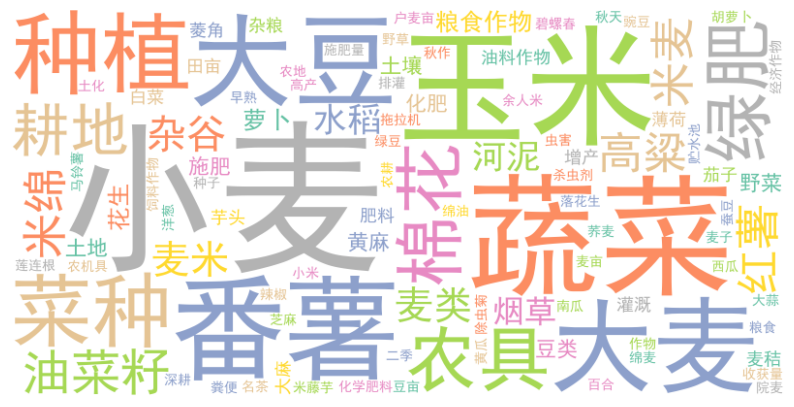

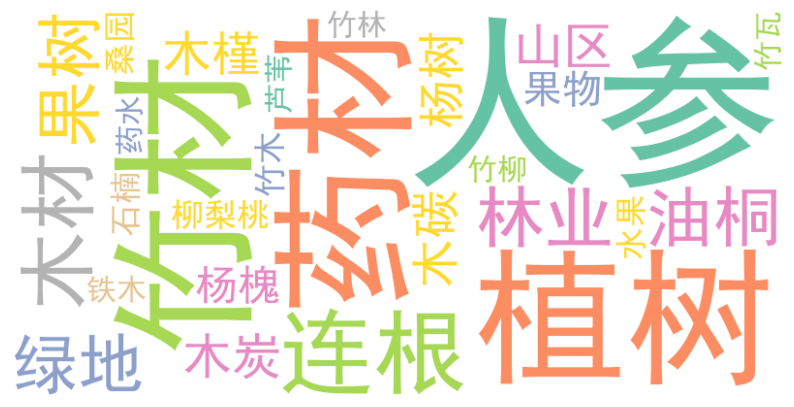

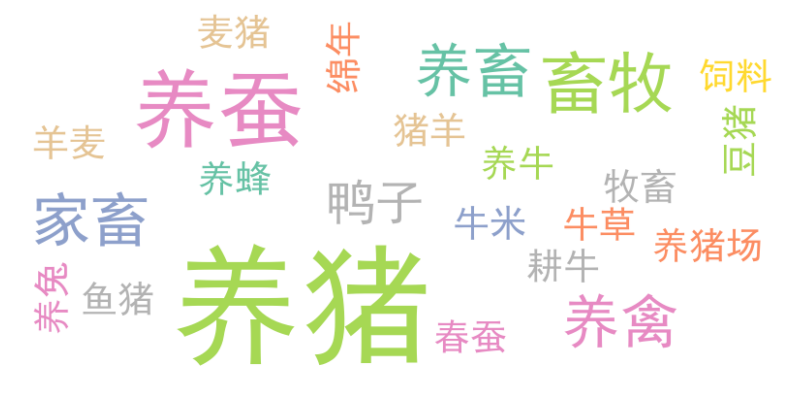

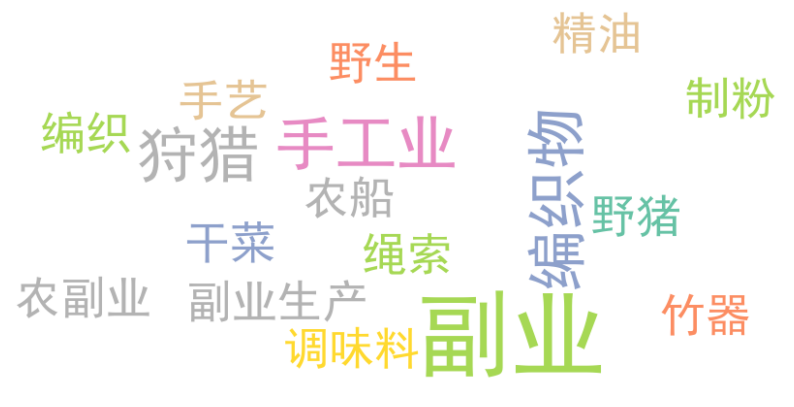

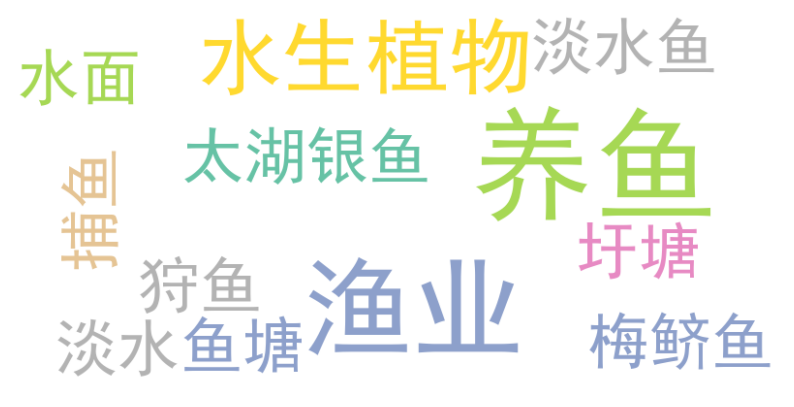

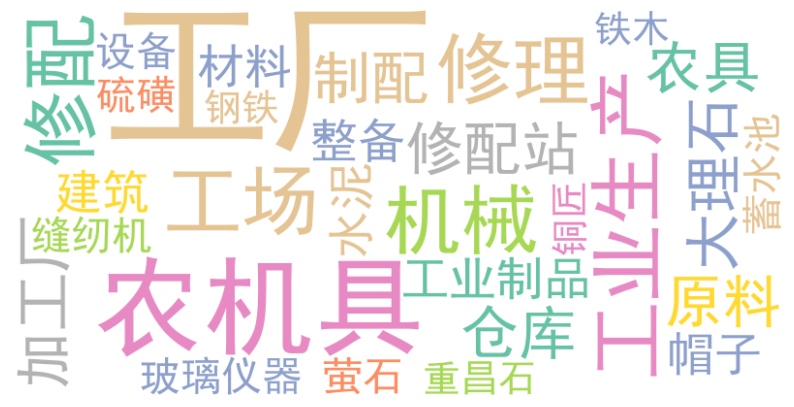

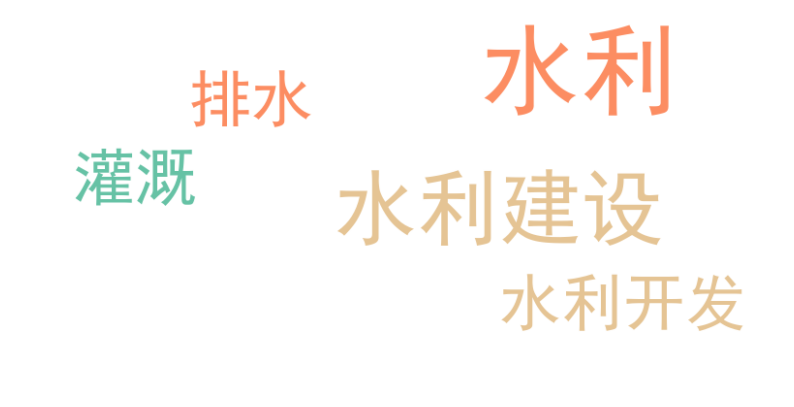

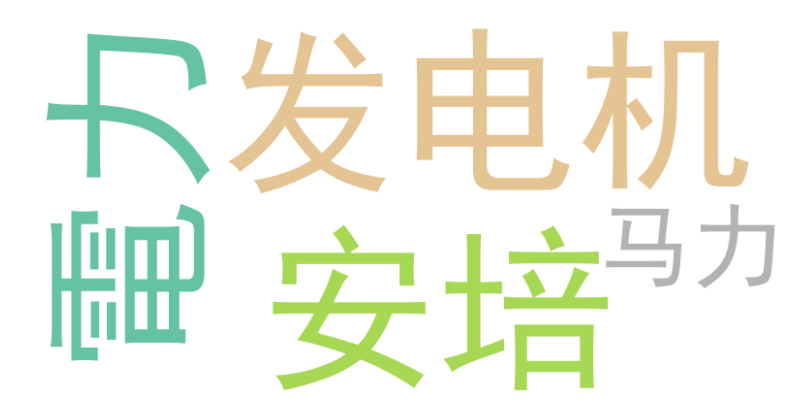

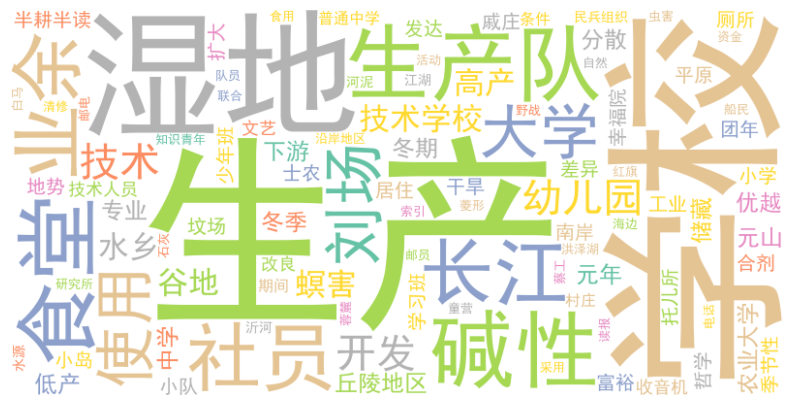

In [7]:
# 绘制词云图
def plot_wordcloud(tfidf_data):
    wordcloud = WordCloud(
        font_path="simhei.ttf",  # 使用支持中文的字体
        width=800,
        height=400,
        background_color='white',
        colormap="Set2"
    ).generate_from_frequencies(tfidf_data)
    
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # 去掉坐标轴
    plt.show()

# 绘制各个小类的词云图
plot_wordcloud(zhongzhi_tfidf)
plot_wordcloud(linye_tfidf)
plot_wordcloud(xumu_tfidf)
plot_wordcloud(fuye_tfidf)
plot_wordcloud(yuye_tfidf)
plot_wordcloud(zhizao_tfidf)
plot_wordcloud(shuili_tfidf)
plot_wordcloud(dianli_tfidf)
plot_wordcloud(other_tfidf)

In [8]:
import os

# 绘制并保存词云图
def plot_wordcloud(tfidf_data, file_path):
    wordcloud = WordCloud(
        font_path="simhei.ttf",  # 使用支持中文的字体
        width=800,
        height=400,
        background_color='white',
        colormap="Set2"
    ).generate_from_frequencies(tfidf_data)
    
    # 创建图形
    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # 去掉坐标轴

    # 保存图像到指定路径，300dpi
    plt.savefig(file_path, dpi=300, bbox_inches='tight')  # dpi=300 保证图像质量
    plt.close()  # 关闭当前图像，防止多图重叠

# 确定保存路径
output_folder = r"E:\【论文】\heritage science\0602analysis\词频图"  # 替换为实际文件夹路径
os.makedirs(output_folder, exist_ok=True)  # 如果文件夹不存在则创建

# 保存各个小类词云图
zhongzhi_file = os.path.join(output_folder, "zhongzhi_wordcloud.png")
plot_wordcloud(zhongzhi_tfidf, zhongzhi_file)

linye_file = os.path.join(output_folder, "linye_wordcloud.png")
plot_wordcloud(linye_tfidf, linye_file)

xumu_file = os.path.join(output_folder, "xumu_wordcloud.png")
plot_wordcloud(xumu_tfidf, xumu_file)

fuye_file = os.path.join(output_folder, "fuye_wordcloud.png")
plot_wordcloud(fuye_tfidf, fuye_file)

yuye_file = os.path.join(output_folder, "yuye_wordcloud.png")
plot_wordcloud(yuye_tfidf, yuye_file)

zhizao_file = os.path.join(output_folder, "zhizao_wordcloud.png")
plot_wordcloud(zhizao_tfidf, zhizao_file)

shuili_file = os.path.join(output_folder, "shuili_wordcloud.png")
plot_wordcloud(shuili_tfidf, shuili_file)

dianli_file = os.path.join(output_folder, "dianli_wordcloud.png")
plot_wordcloud(dianli_tfidf, dianli_file)

other_file = os.path.join(output_folder, "other_wordcloud.png")
plot_wordcloud(other_tfidf, other_file)

print("词云图已保存到指定文件夹。")

词云图已保存到指定文件夹。
